In [1]:
import dhlab as dh
import pandas as pd

In [4]:
c = pd.read_csv("barn.csv", index_col=0, low_memory=False)

In [5]:
c

,dhlabid,urn,lenker,title,authors,oaiid,city,year,publisher,langs,...,ddc,genres,literaryform,kristin,sesamid,isbn10,timestamp,doctype,ocr_creator,ocr_timestamp
78,100289681,URN:NBN:no-nb_digibok_2016041448047,Vis element,Eventyret om fanden i nøtten,"Asbjørnsen , Peter Christen / Moe , Jørgen / M...",NaN,Oslo,1945.0,Damm,nob,...,NaN,NaN,Skjønn,Skjønn,NaN,NaN,NaN,NaN,NaN,NaN
59,100213176,URN:NBN:no-nb_digibok_2014071508018,Vis element,Farlig spill : en guttefortelling,"Ask , Espen / Brandvold , Åshild",NaN,Oslo,1945.0,Ekko,nob,...,NaN,NaN,Skjønn,Skjønn,NaN,NaN,NaN,NaN,NaN,NaN
117,100309755,URN:NBN:no-nb_digibok_2016090948102,Vis element,Finnmarks-Ravna,"Ott , Estrid / Treider , Esther Normann . / Gj...",NaN,Oslo,1945.0,Gyldendal,nob / dan,...,NaN,fiction,Skjønnlitteratur,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,100226008,URN:NBN:no-nb_digibok_2014091708167,Vis element,Flagg over Vangen : forteljing om Vangsgutane,"Halse , Leif / Nilssen , Jens R.",NaN,Oslo,1945.0,Fonna,nno,...,NaN,NaN,Skjønn,Skjønn,NaN,NaN,NaN,NaN,NaN,NaN
24,100572774,URN:NBN:no-nb_digibok_2007011200043,Vis element,Fra 9. april til 7. juni : episoder og oplevel...,"Gotaas , Birger",NaN,NaN,1945.0,Dybwad,nob,...,948.1053,NaN,Fag,Fag,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44359,100691389,URN:NBN:no-nb_pliktmonografi_000030290,Vis element,Tvillingene,"Dahlstrøm, Camilla",oai:nb.bibsys.no:999920479494902202,Oslo,2024.0,Egmont Kids Media Nordic AS,nob,...,741.59481,fiction / tekst / stillbilde,Skjønnlitteratur,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45941,100684562,URN:NBN:no-nb_digibok_2025041548051,NaN,Vitnesbyrd om ondskap – barnelitteratur for vå...,"Mørk, Kjersti Lersbryggen",oai:nb.bibsys.no:999920576802402202,Oslo,2024.0,"Institutt for litteratur, områdestudier og eur...",nob,...,809.89282090511,theses / tekst,Faglitteratur,NaN,84eef5864cf932ee14f60485e35635b3,NaN,20240101.0,digibok,nb,20250702.0
45966,100692059,URN:NBN:no-nb_pliktmonografi_000031198,NaN,Aldri bedre : roman,"Krag, Alexander Kielland / Brynhildsvoll, Jørgen",oai:nb.bibsys.no:999920493001602202,Oslo,2024.0,Gyldendal,nob,...,839.8238,novel / tekst,Skjønnlitteratur,NaN,0218cba485411339956b981ec5d82119,NaN,20240101.0,digibok,nb,20250702.0
44373,100693427,URN:NBN:no-nb_pliktmonografi_000032602,Vis element,Lisa gikk til skogen,"Skomsvold, Kjersti Annesdatter / Vestre, Linnea",oai:nb.bibsys.no:999920508660602202,Oslo,2024.0,Aschehoug,nob,...,839.8238,fiction / tekst,Skjønnlitteratur,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
word_groups = {
  "funksjonsnedsettelse": [
    "handikappet", "funksjonshemmet", "blind", "svaksynt",
    "døv", "tunghørt", "hørselshemmet",
    "klumpfot", "albino",
    "rullestolbruker", "bevegelseshemmet",
    "psykisk utviklingshemmet", "autistisk", "autisme",
    "dyslektiker", "epileptiker"
  ],

  "utseende_kropp": [
    "tykk", "tynn", "høy", "lav", "kraftig", "overvektig",
    "undervektig"
  ],

  "seksuell_legning_kjønn": [
    "trans", "transe", "transkjønnet",
    "homofil", "homse",
    "lesbisk", "lesbe",
    "bi", "bifil",
    "panfil", "aseksuell", "queer"
  ],

  "egennavn": [
    "fornavn", "etternavn", "personnavn", "stedsnavn"
  ],

  "nasjonalitet": [
    "pakistansk", "arabisk", "afrikansk", "grønlender", "grønlandsk",
    "islandsk", "polsk", "russer", "russisk", "amerikaner",
    "hindu", "japaner", "asiat", "kineser", "tysker", "franskmann",
    "britisk", "engelsk", "svensk", "dansk", "finsk",
    "norsk", "samisk", "litauer", "ukrainer", "spanjol", "italiener",
    "portugiser"
  ],

  "geografi": [
    "norden", "europa", "asia", "amerika", "afrika",
    "australia", "antarktis", "arktis", "ural",
    "balkan", "kaukasus", "midtøsten", "skandinavia"
  ],

  "språk": [
    "engelsk", "pakistansk", "urdu",
    "svensk", "dansk", "finsk", "islandsk", "grønlandsk", "samisk",
    "fransk", "tysk", "polsk", "litauisk", "russisk",
    "italiensk", "spansk", "castillano", "portugisisk",
    "kinesisk", "japansk", "tamil", "arabisk", "swahili",
    "norsk", "nynorsk", "bokmål", "latin",
    "gresk", "hebraisk", "persisk", "kurdisk"
  ],

  "religion": [
    "kristendom", "hinduisme", "islam", "muhammedanisme",
    "taoisme", "jødedom", "koptisk", "katolisisme",
    "protestantisme", "ortodoksi", "buddhisme", "sikhisme"
  ],

  "kultur_markorer": [
    "urfolk", "indianer", "araber", "afrikaner",
    "amerikaner", "europeer", "nordisk", "samisk",
    "romfolk", "sinti", "keltisk",
    "innvandrer", "minoritet"
  ]
}

In [12]:
words = [x for y in word_groups for x in word_groups[y]]

In [25]:
mapping = {x:y for y in word_groups for x in word_groups[y]}
    

In [26]:
mapping["innvandrer"]

'kultur_markorer'

In [24]:
#words


In [20]:
urns = [x for x in c.urn.to_list() if isinstance(x, str)]

In [22]:
counts = dh.Counts(corpus = urns, words = words)

In [35]:
counts = counts.frame

In [37]:
counts["group"] = counts.index.map(lambda w: mapping.get(w, None))

In [38]:
counts

urn,100000334,100000453,100001357,100001359,100001386,100001460,100001463,100001486,100001505,100001620,...,100713851,100713863,100714106,100714451,100714471,100715960,100716135,100716271,100721728,group
word,,,,,,,,,,,,,,,,,,,,,
afrika,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi
afrikaner,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kultur_markorer
afrikansk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nasjonalitet
albino,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,funksjonsnedsettelse
amerika,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ukrainer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nasjonalitet
undervektig,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,utseende_kropp
ural,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi


In [83]:
years = c.set_index("dhlabid")["year"].dropna().astype(int)   # eller hvordan du har det

In [104]:
# anta:
# counts: index = ord
#         kolonner = dhlabid ... + 'group'
# years_df: kolonner ['dhlabid', 'year']

# 0: lag en ren years-Series med unik index
years = (
    c
    .drop_duplicates("dhlabid")
    .set_index("dhlabid")["year"]
).dropna().astype(int)

counts.columns = counts.columns.astype(str)
c["dhlabid"] = c["dhlabid"].astype(str)

# 1: dokumentkolonnene i counts (alle unntatt 'group')
doc_cols = counts.columns.drop("group")

# 2: felles dhlabid mellom counts og years
common = doc_cols.intersection(years.index)

# 3: trekk ut bare de dokumentene vi har både counts og år for
X = counts[common]              # ord × dokument
years_valid = years.loc[common] # index = dhlabid, value = år

In [105]:
# 4: ord × år (summerer alle docs med samme år)
word_by_year = X.groupby(years_valid, axis=1).sum()

# 5: grupper × år
group_by_year = (
    word_by_year
    .assign(group=counts["group"])
    .groupby("group")
    .sum()                      # her forsvinner 'group'-kolonnen, år-kolonner blir igjen
    .sort_index(axis=1)         # sortér år langs kolonne-aksen
)

/tmp/ipykernel_735600/234373164.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  word_by_year = X.groupby(years_valid, axis=1).sum()


In [106]:
group_by_year

year,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
group,,,,,,,,,,,,,,,,,,,,,
egennavn,20.0,14.0,25.0,18.0,34.0,37.0,15.0,24.0,23.0,23.0,...,154.0,172.0,165.0,116.0,107.0,34.0,25.0,31.0,13.0,5.0
funksjonsnedsettelse,107.0,64.0,82.0,104.0,121.0,175.0,124.0,142.0,104.0,99.0,...,485.0,579.0,426.0,488.0,348.0,102.0,83.0,31.0,15.0,14.0
geografi,3.0,2.0,0.0,14.0,0.0,2.0,2.0,3.0,0.0,1.0,...,6.0,8.0,10.0,5.0,1.0,1.0,3.0,2.0,0.0,0.0
kultur_markorer,167.0,107.0,90.0,69.0,161.0,209.0,143.0,148.0,118.0,149.0,...,213.0,229.0,279.0,270.0,105.0,44.0,168.0,65.0,39.0,6.0
nasjonalitet,83.0,147.0,110.0,102.0,136.0,204.0,94.0,158.0,65.0,82.0,...,248.0,262.0,265.0,160.0,97.0,45.0,58.0,67.0,12.0,3.0
religion,28.0,19.0,21.0,6.0,45.0,13.0,14.0,15.0,20.0,7.0,...,99.0,92.0,207.0,120.0,113.0,9.0,11.0,70.0,9.0,4.0
seksuell_legning_kjønn,32.0,55.0,50.0,43.0,69.0,96.0,40.0,91.0,41.0,33.0,...,284.0,250.0,563.0,217.0,237.0,129.0,81.0,15.0,9.0,7.0
språk,1319.0,1136.0,1272.0,1122.0,2035.0,1939.0,1260.0,1363.0,812.0,768.0,...,4659.0,3793.0,4420.0,3566.0,2494.0,932.0,976.0,758.0,374.0,99.0
utseende_kropp,1376.0,1557.0,1777.0,1721.0,2231.0,2616.0,1829.0,2194.0,1554.0,1615.0,...,7446.0,6489.0,6263.0,5576.0,4090.0,1521.0,917.0,680.0,231.0,116.0


In [107]:
# grupper × år  →  år × grupper
T = group_by_year.T

# glatt over år (langs index, ingen axis-argument)
smooth_T = T.rolling(window=5, center=True).mean()

# tilbake til grupper × år
smooth = smooth_T

<Axes: xlabel='year'>

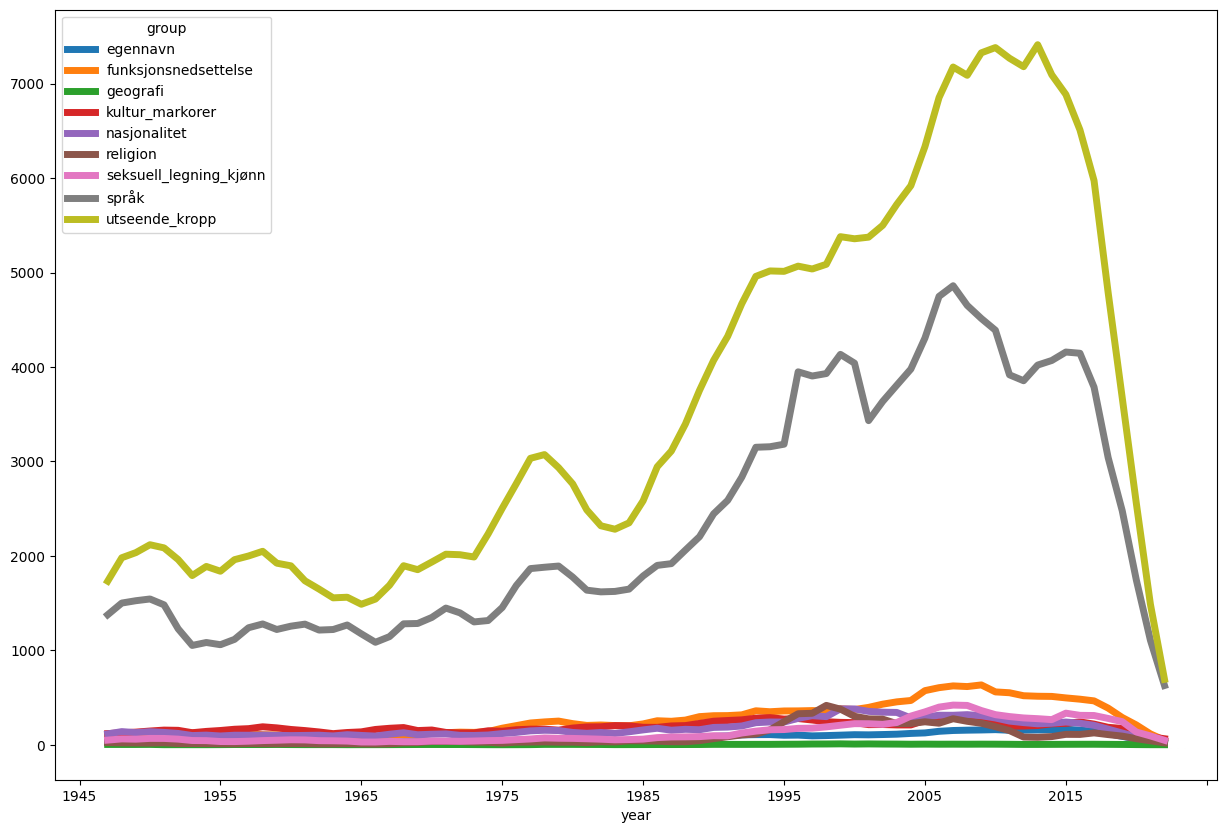

In [108]:
smooth.plot(lw=5)

In [109]:
# grupper × år
group_norm_cohort = group_by_year.div(group_by_year.sum(axis=1), axis=0)

<Axes: xlabel='year'>

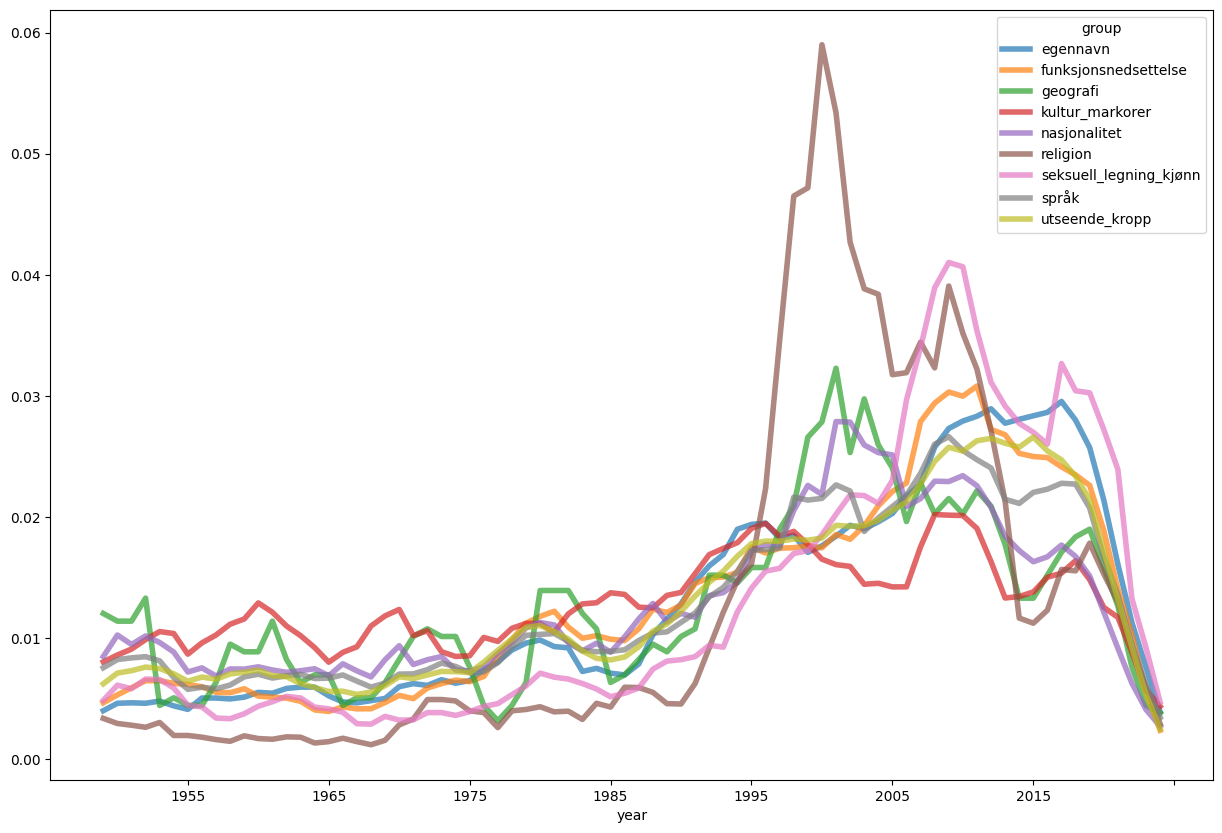

In [110]:
group_norm_cohort.T.rolling(window=5).mean().plot(lw=4, alpha=0.7)

In [111]:
group_norm_year = group_by_year.div(group_by_year.sum(axis=0), axis=1)

<Axes: xlabel='year'>

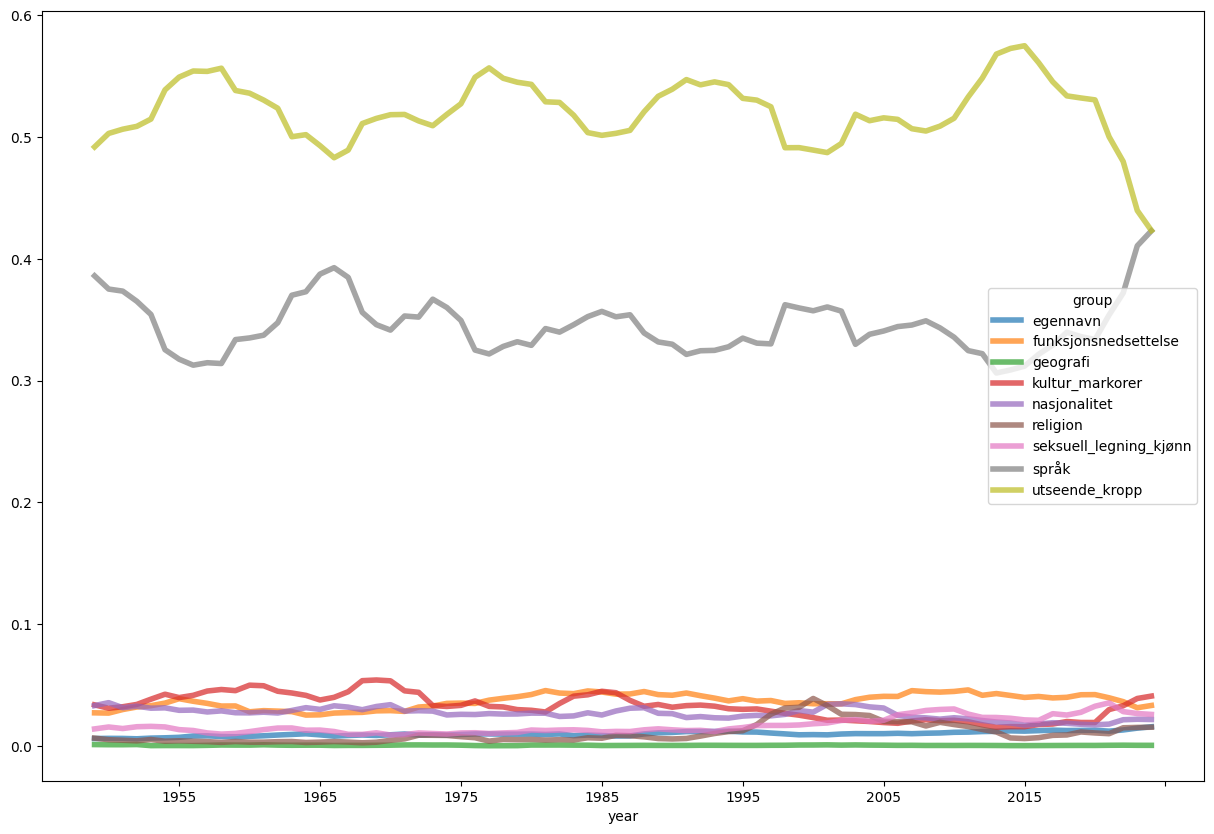

In [112]:
group_norm_year.T.rolling(window=5).mean().plot(lw=4, alpha=0.7)

In [113]:
group_norm_year.T.index

Index([1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956,
       1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968,
       1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='object', name='year')

<Axes: xlabel='year'>

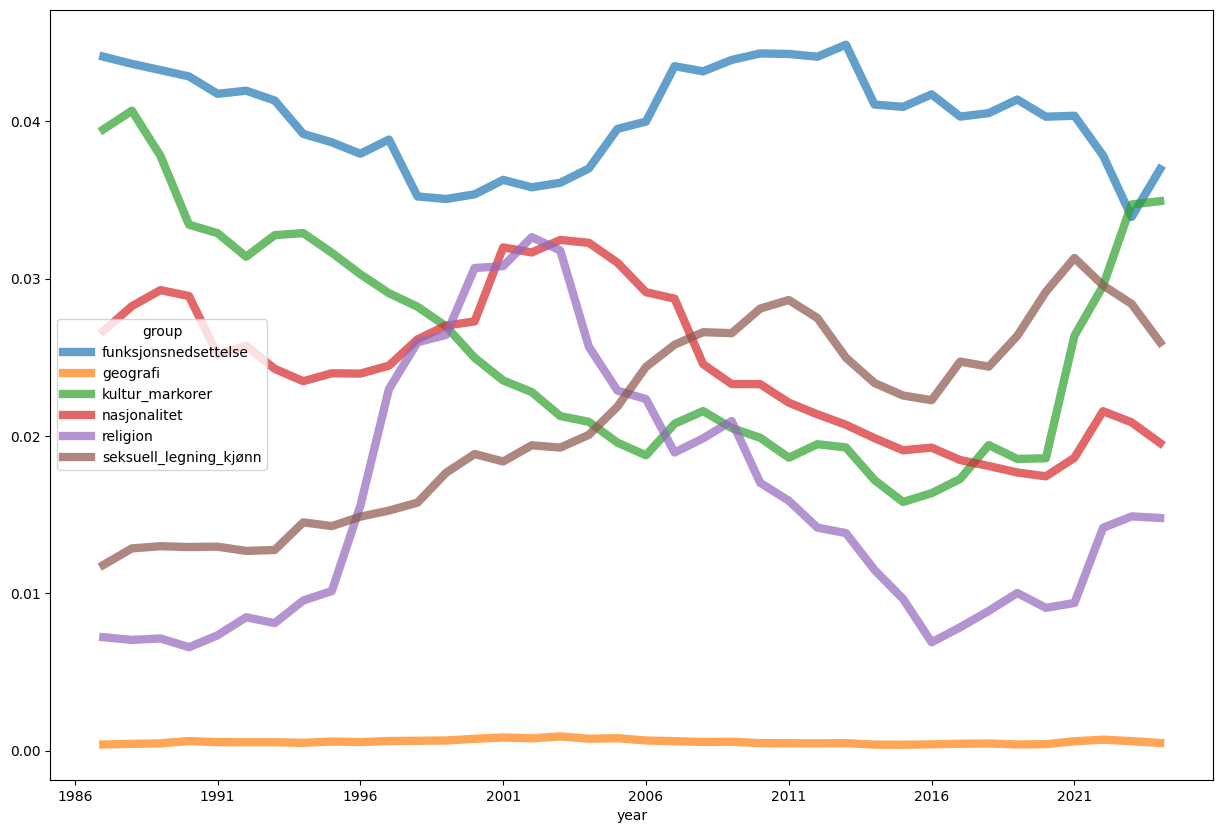

In [122]:
df = group_norm_year.loc[['funksjonsnedsettelse', 'geografi', 'kultur_markorer',
       'nasjonalitet', 'religion', 'seksuell_legning_kjønn']].T
df[df.index > 1980].rolling(window=7).mean().plot(lw=6, alpha=0.7)

In [123]:

# antall forekomster per ord og gruppe (du har counts + group)
word_totals = counts.drop(columns=["group"]).sum(axis=1)       # total frekvens per ord
word_totals = word_totals.to_frame("freq").assign(group=counts["group"])

# velg én gruppe
g = "kultur_markorer"
cands = word_totals.query("group == @g").sort_values("freq", ascending=False)

# ta f.eks. topp 10 ord i denne gruppen
top_words = cands.head(10).index.tolist()
top_words

['indianer',
 'samisk',
 'amerikaner',
 'nordisk',
 'araber',
 'europeer',
 'keltisk',
 'afrikaner',
 'innvandrer',
 'minoritet']